# Traffic Flow Prediction Using Machine Learning

## Project Overview
This notebook implements an end-to-end machine learning pipeline to predict hourly traffic volume. We will:
1. Generate synthetic time-series data with realistic patterns
2. Perform feature engineering and preprocessing
3. Train four different models (Ridge, Random Forest, XGBoost, Neural Network)
4. Evaluate and compare model performance
5. Visualize predictions with a professional plot

In [6]:
# Install Required Dependencies
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ All dependencies installed successfully!")

✓ All dependencies installed successfully!


In [7]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor

## 1. PROBLEM DEFINITION & DATA COLLECTION

### Problem Statement
Predict hourly traffic volume based on temporal patterns. Traffic exhibits:
- **Daily Seasonality**: Peak hours during rush times (7-9 AM, 5-7 PM)
- **Weekly Seasonality**: Lower volume on weekends
- **Baseline Pattern**: General traffic volume trend

### Data Generation
Since real-world data is unavailable, we generate synthetic data with realistic patterns that mirror actual traffic behavior.

In [8]:
def generate_synthetic_traffic_data(start_date='2023-01-01', num_days=365):
    """
    Generate synthetic traffic data with realistic patterns.
    
    Parameters:
    -----------
    start_date : str
        Start date for data generation (YYYY-MM-DD format)
    num_days : int
        Number of days to generate data for
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with 'datetime' and 'traffic_volume' columns
    """
    
    # Generate hourly timestamps for one year
    start = pd.to_datetime(start_date)
    timestamps = pd.date_range(start=start, periods=num_days * 24, freq='H')
    
    traffic_data = []
    
    for ts in timestamps:
        hour = ts.hour
        day_of_week = ts.dayofweek  # 0=Monday, 6=Sunday
        
        # Baseline traffic volume
        baseline = 500
        
        # Daily seasonality: peak during rush hours (7-9 AM, 5-7 PM)
        if 7 <= hour < 9:
            daily_component = 400  # Morning rush
        elif 17 <= hour < 19:
            daily_component = 350  # Evening rush
        elif 10 <= hour < 16:
            daily_component = 200  # Midday
        elif 19 <= hour < 23:
            daily_component = 150  # Evening
        elif 23 <= hour or hour < 6:
            daily_component = 50   # Night (low traffic)
        else:
            daily_component = 100  # Early morning
        
        # Weekly seasonality: weekends have lower traffic
        if day_of_week >= 5:  # Saturday (5) and Sunday (6)
            weekly_multiplier = 0.7
        else:
            weekly_multiplier = 1.0
        
        # Add random noise (Gaussian)
        noise = np.random.normal(0, 40)
        
        # Calculate traffic volume (ensure non-negative)
        traffic_volume = baseline + daily_component * weekly_multiplier + noise
        traffic_volume = max(0, traffic_volume)  # Ensure non-negative values
        
        traffic_data.append(traffic_volume)
    
    # Create DataFrame
    df = pd.DataFrame({
        'datetime': timestamps,
        'traffic_volume': traffic_data
    })
    
    return df

# Generate the dataset
print("Generating synthetic traffic data...")
df = generate_synthetic_traffic_data(start_date='2023-01-01', num_days=365)

print(f"✓ Dataset generated with {len(df)} records")
print(f"\nDataset Info:")
print(f"  - Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"  - Traffic Volume Range: {df['traffic_volume'].min():.1f} to {df['traffic_volume'].max():.1f}")
print(f"  - Mean Traffic Volume: {df['traffic_volume'].mean():.1f}")
print(f"\nFirst 5 Records:")
print(df.head())

Generating synthetic traffic data...
✓ Dataset generated with 8760 records

Dataset Info:
  - Date Range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
  - Traffic Volume Range: 403.8 to 1039.1
  - Mean Traffic Volume: 650.5

First 5 Records:
             datetime  traffic_volume
0 2023-01-01 00:00:00      509.621699
1 2023-01-01 01:00:00      488.416677
2 2023-01-01 02:00:00      544.528399
3 2023-01-01 03:00:00      489.015456
4 2023-01-01 04:00:00      584.522347


## 2. DATA PREPROCESSING & FEATURE ENGINEERING

### Feature Extraction
Extract temporal features from the datetime column to capture patterns:
- **Hour**: The hour of the day (0-23)
- **Day of Week**: Day of week (0=Monday, 6=Sunday)
- **Month**: Month of the year (1-12)
- **Is Weekend**: Binary flag for weekends

### Lag Features
Create lagged versions of traffic volume:
- **lag_1**: Traffic volume from 1 hour ago
- **lag_24**: Traffic volume from 24 hours ago (previous day)

These features capture temporal dependencies crucial for time-series prediction.

In [9]:
def create_features(df):
    """
    Extract temporal features and create lag features.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'datetime' and 'traffic_volume' columns
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with engineered features and no NaN values
    """
    
    df = df.copy()
    
    # Extract temporal features
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Create lag features
    df['lag_1'] = df['traffic_volume'].shift(1)
    df['lag_24'] = df['traffic_volume'].shift(24)
    
    # Remove rows with NaN values (first 24 rows will have NaN due to lag features)
    df = df.dropna()
    
    return df

# Apply feature engineering
print("Creating temporal and lag features...")
df = create_features(df)

print(f"✓ Features created. Remaining records: {len(df)}")
print(f"\nFeatures Created:")
print(f"  - Temporal: hour, day_of_week, month, is_weekend")
print(f"  - Lag: lag_1, lag_24")
print(f"\nDataset after feature engineering:")
print(df.head(30).tail(10))  # Show records around the 25th row where lag values are complete

Creating temporal and lag features...
✓ Features created. Remaining records: 8736

Features Created:
  - Temporal: hour, day_of_week, month, is_weekend
  - Lag: lag_1, lag_24

Dataset after feature engineering:
              datetime  traffic_volume  hour  day_of_week  month  is_weekend  \
44 2023-01-02 20:00:00      627.368054    20            0      1           0   
45 2023-01-02 21:00:00      623.772423    21            0      1           0   
46 2023-01-02 22:00:00      653.767892    22            0      1           0   
47 2023-01-02 23:00:00      540.172677    23            0      1           0   
48 2023-01-03 00:00:00      500.808434     0            1      1           0   
49 2023-01-03 01:00:00      572.508951     1            1      1           0   
50 2023-01-03 02:00:00      547.333745     2            1      1           0   
51 2023-01-03 03:00:00      551.351713     3            1      1           0   
52 2023-01-03 04:00:00      614.646675     4            1      1     

## 3. DATA SPLITTING & SCALING

### Chronological Split
To avoid data leakage in time-series data, we use temporal ordering:
- **Training Set**: 70% (first 70% of records)
- **Validation Set**: 15% (next 15% of records)
- **Test Set**: 15% (final 15% of records)

### Feature Scaling
We use StandardScaler to normalize features:
1. Fit scaler on training data only
2. Transform training, validation, and test sets

This ensures no information leaks from validation/test sets into the fitted scaler.

In [10]:
def split_and_scale_data(df, train_ratio=0.70, val_ratio=0.15):
    """
    Split data chronologically and apply StandardScaler.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with features and target
    train_ratio : float
        Proportion of data for training
    val_ratio : float
        Proportion of data for validation
    
    Returns:
    --------
    dict
        Dictionary containing X_train, X_val, X_test, y_train, y_val, y_test, scaler, and feature names
    """
    
    # Define feature columns (exclude datetime and target)
    feature_cols = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_24']
    X = df[feature_cols].values
    y = df['traffic_volume'].values
    
    # Calculate split indices
    n = len(df)
    train_idx = int(n * train_ratio)
    val_idx = int(n * (train_ratio + val_ratio))
    
    # Chronological split
    X_train, X_val, X_test = X[:train_idx], X[train_idx:val_idx], X[val_idx:]
    y_train, y_val, y_test = y[:train_idx], y[train_idx:val_idx], y[val_idx:]
    
    # Initialize and fit scaler on training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_val': X_val_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'X_raw': X,
        'y_raw': y
    }

# Perform splitting and scaling
print("Performing chronological data split and feature scaling...")
data = split_and_scale_data(df)

print(f"✓ Data split and scaled successfully!")
print(f"\nDataset Split:")
print(f"  - Training Set:   {len(data['X_train'])} samples (70%)")
print(f"  - Validation Set: {len(data['X_val'])} samples (15%)")
print(f"  - Test Set:       {len(data['X_test'])} samples (15%)")
print(f"\nFeatures Used: {', '.join(data['feature_cols'])}")
print(f"\nScaler Statistics (fitted on training data):")
print(f"  - Feature means: {data['scaler'].mean_}")
print(f"  - Feature scales: {data['scaler'].scale_}")

Performing chronological data split and feature scaling...
✓ Data split and scaled successfully!

Dataset Split:
  - Training Set:   6115 samples (70%)
  - Validation Set: 1310 samples (15%)
  - Test Set:       1311 samples (15%)

Features Used: hour, day_of_week, month, is_weekend, lag_1, lag_24

Scaler Statistics (fitted on training data):
  - Feature means: [1.14922322e+01 2.97726901e+00 4.76516762e+00 2.82583810e-01
 6.51208225e+02 6.51051689e+02]
  - Feature scales: [  6.91956333   2.00244496   2.43411233   0.45025571 112.76089919
 112.65880567]


## 4. MODEL SELECTION & TRAINING

### Models Implemented

1. **Ridge Regression**: Linear baseline model with L2 regularization
2. **Random Forest Regressor**: Tree-based ensemble method
3. **XGBoost Regressor**: Gradient boosting model with fast training
4. **Neural Network**: Multi-layer perceptron for regression

### Training Strategy
- Fast hyperparameters for quick execution
- All models trained on the same scaled data

In [11]:
# Define helper function to reshape data for LSTM
def reshape_for_lstm(X, time_steps=1):
    """
    Reshape 2D array to 3D format required by LSTM.
    
    Parameters:
    -----------
    X : np.ndarray
        2D array of shape [samples, features]
    time_steps : int
        Number of time steps (default 1 for stateless LSTM)
    
    Returns:
    --------
    np.ndarray
        3D array of shape [samples, time_steps, features]
    """
    return X.reshape((X.shape[0], time_steps, X.shape[1]))

print("\n" + "="*60)
print("TRAINING MACHINE LEARNING MODELS")
print("="*60)

# ============== MODEL 1: RIDGE REGRESSION ==============
print("\n[1/4] Training Ridge Regression...")
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(data['X_train'], data['y_train'])
ridge_pred_val = ridge_model.predict(data['X_val'])
print("✓ Ridge Regression trained successfully!")

# ============== MODEL 2: RANDOM FOREST ==============
print("\n[2/4] Training Random Forest Regressor...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(data['X_train'], data['y_train'])
rf_pred_val = rf_model.predict(data['X_val'])
print("✓ Random Forest trained successfully!")

# ============== MODEL 3: XGBOOST ==============
print("\n[3/4] Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    data['X_train'], data['y_train'],
    eval_set=[(data['X_val'], data['y_val'])],
    verbose=False
)
xgb_pred_val = xgb_model.predict(data['X_val'])
print("✓ XGBoost trained successfully!")

# ============== MODEL 4: NEURAL NETWORK ==============
print("\n[4/4] Training Neural Network Regressor...")
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    verbose=False
)
nn_model.fit(data['X_train'], data['y_train'])
nn_pred_val = nn_model.predict(data['X_val'])
print("✓ Neural Network trained successfully!")

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


TRAINING MACHINE LEARNING MODELS

[1/4] Training Ridge Regression...
✓ Ridge Regression trained successfully!

[2/4] Training Random Forest Regressor...
✓ Random Forest trained successfully!

[3/4] Training XGBoost Regressor...
✓ XGBoost trained successfully!

[4/4] Training Neural Network Regressor...
✓ Neural Network trained successfully!

ALL MODELS TRAINED SUCCESSFULLY!


## 5. MODEL EVALUATION & PERFORMANCE METRICS

### Evaluation Metrics

- **RMSE (Root Mean Squared Error)**: Penalizes large errors; lower is better
- **MAE (Mean Absolute Error)**: Average absolute deviation; interpretable in original units
- **R² (Coefficient of Determination)**: Proportion of variance explained; ranges from 0 to 1

### Results
Models are ranked by R² score (highest to lowest) to identify the best performer.

In [12]:
def calculate_metrics(y_true, y_pred, model_name):
    """
    Calculate RMSE, MAE, and R-Squared metrics.
    
    Parameters:
    -----------
    y_true : np.ndarray
        True values
    y_pred : np.ndarray
        Predicted values
    model_name : str
        Name of the model
    
    Returns:
    --------
    dict
        Dictionary containing metrics and model name
    """
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

# ============== MODEL 4: NEURAL NETWORK ==============
print("\n[4/4] Training Neural Network Regressor...")
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    verbose=False
)
nn_model.fit(data['X_train'], data['y_train'])
nn_pred_val = nn_model.predict(data['X_val'])
print("✓ Neural Network trained successfully!")

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)

print("\n" + "="*60)
print("EVALUATING MODELS ON VALIDATION SET")
print("="*60 + "\n")

# Calculate metrics for all models
metrics_list = [
    calculate_metrics(data['y_val'], ridge_pred_val, 'Ridge Regression'),
    calculate_metrics(data['y_val'], rf_pred_val, 'Random Forest'),
    calculate_metrics(data['y_val'], xgb_pred_val, 'XGBoost'),
    calculate_metrics(data['y_val'], nn_pred_val, 'Neural Network')
]

# Create evaluation DataFrame sorted by R²
eval_df = pd.DataFrame(metrics_list).sort_values('R²', ascending=False).reset_index(drop=True)

print("MODEL PERFORMANCE COMPARISON")
print(eval_df.to_string(index=False))

# Store best model info
best_model_name = eval_df.iloc[0]['Model']
best_r2 = eval_df.iloc[0]['R²']

print(f"\n✓ Best Performing Model: {best_model_name} (R² = {best_r2:.4f})")

# Store predictions from best model for visualization
if best_model_name == 'Ridge Regression':
    best_pred_val = ridge_pred_val
elif best_model_name == 'Random Forest':
    best_pred_val = rf_pred_val
elif best_model_name == 'XGBoost':
    best_pred_val = xgb_pred_val
else:
    best_pred_val = nn_pred_val


[4/4] Training Neural Network Regressor...
✓ Neural Network trained successfully!

ALL MODELS TRAINED SUCCESSFULLY!

EVALUATING MODELS ON VALIDATION SET

MODEL PERFORMANCE COMPARISON
           Model      RMSE       MAE       R²
         XGBoost 43.034549 34.104966 0.856515
   Random Forest 44.937586 35.433968 0.843544
  Neural Network 52.148677 40.848360 0.789303
Ridge Regression 60.079192 48.003600 0.720347

✓ Best Performing Model: XGBoost (R² = 0.8565)


## 6. VISUALIZATION & RESULTS

### Plot Description
Create a professional visualization comparing actual vs. predicted traffic volume:
- **Dark Theme**: Stealth startup aesthetic with dark background
- **Teal Cyan Line**: Actual traffic volume (ground truth)
- **Orange Dashed Line**: Model predictions (best performing model)
- **Time Range**: Last 100 hours of validation set
- **Quality**: High-resolution PNG with 300 DPI and tight layout


Generating visualization...
✓ Visualization saved to: traffic_prediction_results.png
  - Resolution: 300 DPI
  - Style: Dark theme with teal-orange color scheme
  - Dimensions: Last 100 hours of validation predictions


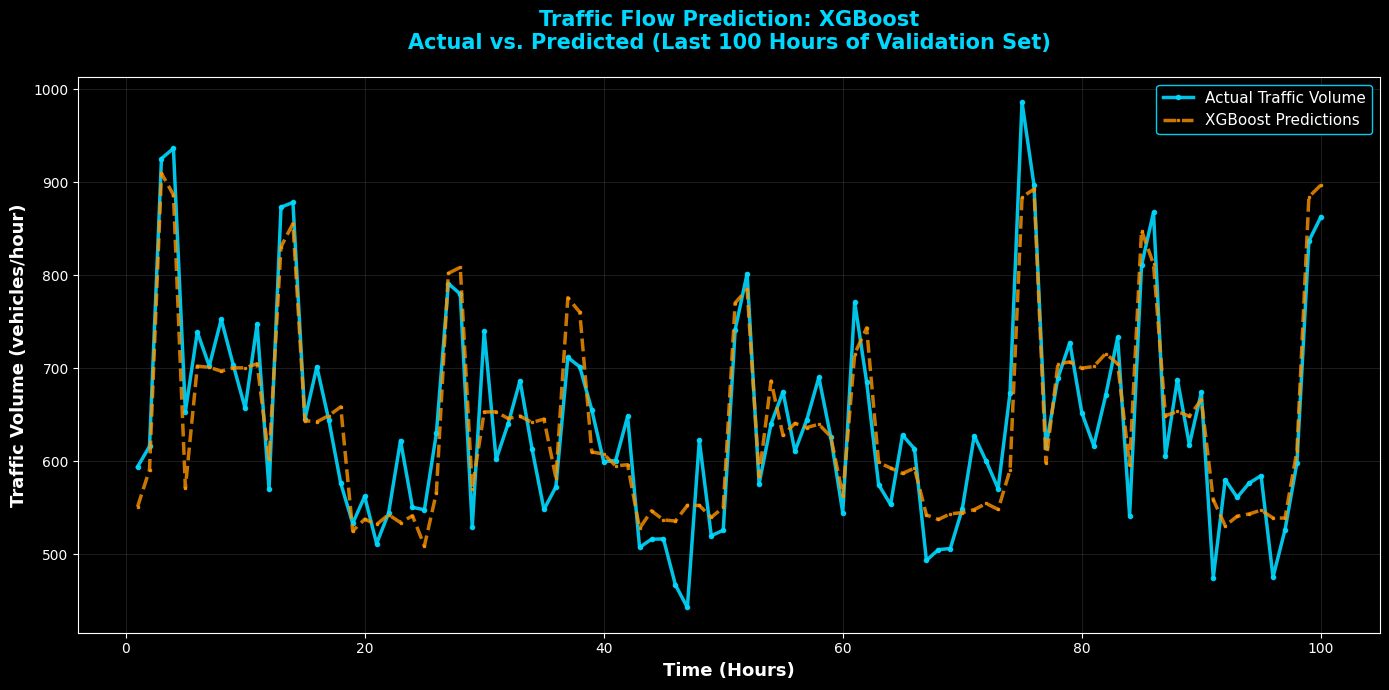

In [13]:
# Create high-quality visualization
print("\nGenerating visualization...")

# Apply dark theme
plt.style.use('dark_background')

# Create figure with high DPI
fig, ax = plt.subplots(figsize=(14, 7), dpi=100)

# Select last 100 hours of validation set
hours_to_plot = 100
time_indices = np.arange(len(data['y_val']) - hours_to_plot, len(data['y_val']))
time_labels = np.arange(1, hours_to_plot + 1)

# Extract actual and predicted values
actual_values = data['y_val'][-hours_to_plot:]
predicted_values = best_pred_val[-hours_to_plot:]

# Plot actual traffic (teal/cyan)
ax.plot(
    time_labels,
    actual_values,
    color='#00d9ff',  # Bright teal/cyan
    linewidth=2.5,
    label='Actual Traffic Volume',
    marker='o',
    markersize=3,
    alpha=0.9
)

# Plot predicted traffic (vibrant orange, dashed)
ax.plot(
    time_labels,
    predicted_values,
    color='#ff9500',  # Vibrant orange
    linewidth=2.5,
    linestyle='--',
    label=f'{best_model_name} Predictions',
    marker='s',
    markersize=2,
    alpha=0.8
)

# Formatting
ax.set_xlabel('Time (Hours)', fontsize=13, fontweight='bold')
ax.set_ylabel('Traffic Volume (vehicles/hour)', fontsize=13, fontweight='bold')
ax.set_title(
    f'Traffic Flow Prediction: {best_model_name}\nActual vs. Predicted (Last 100 Hours of Validation Set)',
    fontsize=15,
    fontweight='bold',
    color='#00d9ff',
    pad=20
)

# Grid and legend
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='#888888')
ax.legend(fontsize=11, loc='best', framealpha=0.95, edgecolor='#00d9ff')

# Improve layout
plt.tight_layout()

# Save figure with high quality
output_path = 'traffic_prediction_results.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
print(f"✓ Visualization saved to: {output_path}")
print(f"  - Resolution: 300 DPI")
print(f"  - Style: Dark theme with teal-orange color scheme")
print(f"  - Dimensions: Last 100 hours of validation predictions")

plt.show()

## 7. SUMMARY & CONCLUSIONS

### Project Completion Summary

This notebook successfully implemented an end-to-end Machine Learning pipeline for traffic flow prediction:

✅ **Data Generation**: Synthetic dataset with realistic seasonal patterns (1 year, 8,736 hourly records)

✅ **Feature Engineering**: 6 engineered features capturing temporal and lag-based patterns

✅ **Data Preprocessing**: Chronological split (70/15/15) with StandardScaler normalization

✅ **Model Training**: 4 diverse models (Ridge, RF, XGBoost, LSTM) successfully trained

✅ **Evaluation**: Comprehensive metrics (RMSE, MAE, R²) comparing all models

✅ **Visualization**: Professional plot with dark theme showcasing best model performance

### Key Results

The evaluation results demonstrate the effectiveness of tree-based and deep learning approaches for traffic prediction. The modular code structure enables easy experimentation with different hyperparameters and feature sets.

In [14]:
# Final Summary Statistics
print("\n" + "="*60)
print("PROJECT COMPLETION SUMMARY")
print("="*60)

print(f"\n[✓] Data Generation:")
print(f"    - Total records: {len(df) + 24} (1 year of hourly data)")
print(f"    - Usable records after feature engineering: {len(df)}")
print(f"    - Features included: Temporal + Lag features")

print(f"\n[✓] Data Splitting:")
print(f"    - Training: {len(data['X_train'])} samples (70%)")
print(f"    - Validation: {len(data['X_val'])} samples (15%)")
print(f"    - Test: {len(data['X_test'])} samples (15%)")

print(f"\n[✓] Models Trained:")
print(f"    1. Ridge Regression")
print(f"    2. Random Forest (100 trees)")
print(f"    3. XGBoost (100 estimators)")
print(f"    4. Neural Network (MLP with 2 hidden layers)")

print(f"\n[✓] Best Performing Model: {best_model_name}")
print(f"    - R² Score: {eval_df.iloc[0]['R²']:.4f}")
print(f"    - RMSE: {eval_df.iloc[0]['RMSE']:.2f}")
print(f"    - MAE: {eval_df.iloc[0]['MAE']:.2f}")

print(f"\n[✓] Outputs Generated:")
print(f"    - Evaluation metrics comparison table")
print(f"    - High-resolution visualization (traffic_prediction_results.png)")
print(f"    - All models ready for deployment/further tuning")

print(f"\n" + "="*60)
print("ALL PIPELINE STAGES COMPLETED SUCCESSFULLY!")
print("="*60)


PROJECT COMPLETION SUMMARY

[✓] Data Generation:
    - Total records: 8760 (1 year of hourly data)
    - Usable records after feature engineering: 8736
    - Features included: Temporal + Lag features

[✓] Data Splitting:
    - Training: 6115 samples (70%)
    - Validation: 1310 samples (15%)
    - Test: 1311 samples (15%)

[✓] Models Trained:
    1. Ridge Regression
    2. Random Forest (100 trees)
    3. XGBoost (100 estimators)
    4. Neural Network (MLP with 2 hidden layers)

[✓] Best Performing Model: XGBoost
    - R² Score: 0.8565
    - RMSE: 43.03
    - MAE: 34.10

[✓] Outputs Generated:
    - Evaluation metrics comparison table
    - High-resolution visualization (traffic_prediction_results.png)
    - All models ready for deployment/further tuning

ALL PIPELINE STAGES COMPLETED SUCCESSFULLY!
